# Neural Network in Pytorch


We will learn how to build a Neural Network for modelling a classification task. We will follow most of the workflow as the previous chapter. Here is what this notebook will look like.

1. Getting our Data
2. Building the Neural Network
3. Training our model
4. Inference and Evaluation
5. Further work

In [2]:
import torch
import sklearn

# Getting and Processing our data

We will generate spiral data. Circular/Spiral Data is a well studied problem in classification. The goal is to have the model learn a hyperplance that seperates these classes (and this may/may not exist in the 2-d world this data originally lives in)

In [36]:
# Generating data
from sklearn.datasets import make_circles
n_samples = 1000
X,y = make_circles(n_samples, noise = 0.03, random_state = 42)

print("X data:",X[:5])
print("Y data", y[:5])

X data: [[ 0.75424625  0.23148074]
 [-0.75615888  0.15325888]
 [-0.81539193  0.17328203]
 [-0.39373073  0.69288277]
 [ 0.44220765 -0.89672343]]
Y data [1 1 1 1 0]


In [27]:
# Make DataFrame of circle data
import pandas as pd
circles = pd.DataFrame({"X1": X[:, 0],
    "X2": X[:, 1],
    "label": y
})
circles.head(10)

,X1,X2,label
0,0.754246,0.231481,1
1,-0.756159,0.153259,1
2,-0.815392,0.173282,1
3,-0.393731,0.692883,1
4,0.442208,-0.896723,0
5,-0.479646,0.676435,1
6,-0.013648,0.803349,1
7,0.771513,0.147760,1
8,-0.169322,-0.793456,1
9,-0.121486,1.021509,0


As you can see, each datapoint is assigned to one of two classes(0 or 1). This makes this a **binary classification** problem.

In [28]:
# Get the counts of each class

df_counts = circles.label.value_counts()
df_counts

,count
label,
1,500
0,500


We have a perfect balance here. This will not be the case for many projects you will work on. [This](https://medium.com/data-science/class-imbalance-strategies-a-visual-guide-with-code-8bc8fae71e1a) might be useful.

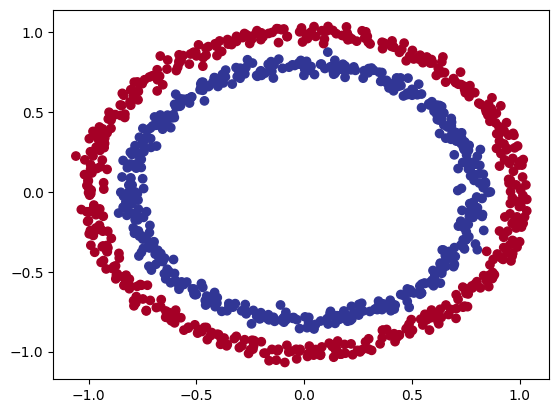

In [29]:
# Visualize with a plot
import matplotlib.pyplot as plt
plt.scatter(x=X[:, 0],
            y=X[:, 1],
            c=y,
            cmap=plt.cm.RdYlBu);

The graph makes it clear. We will use a model to learn the hyperplane to seperate these classes.


In [7]:
# More info about the data

X.shape, y.shape

((1000, 2), (1000,))

This means that X has 1000 rows and two columns (X1 and X2, the two coordinates), and Y has a 1000 datapoints.

In [8]:
# View the first example of features and labels
X_sample = X[0]
y_sample = y[0]
print(f"Values for one sample of X: {X_sample} and the same for y: {y_sample}")
print(f"Shapes for one sample of X: {X_sample.shape} and the same for y: {y_sample.shape}")

Values for one sample of X: [0.75424625 0.23148074] and the same for y: 1
Shapes for one sample of X: (2,) and the same for y: ()


## Turn into tensors and train and test splits.

We already covered a lot of this in detail in the last tutorial so I would not go into much commentary here.

In [41]:
# Turn data into tensors
# Otherwise this causes issues with computations later on
import torch
X = torch.from_numpy(X).type(torch.float).to(device) # Assign the result back to X
y = torch.from_numpy(y).type(torch.float).to(device) # Assign the result back to y

# View the first 10 samples
X[:10], y[:10]

TypeError: expected np.ndarray (got Tensor)

In [38]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.2, random_state = 42)
len(X_train), len(X_test), len(y_train), len(y_test)


(800, 200, 800, 200)

# Let's build our model!


We will build a neural network. We will follow the following steps:

1. Choose device
2. Build a model using nn.Module
3. Define a loss function and optimizer

In [1]:
# Choose device
# Standard PyTorch imports
import torch
from torch import nn

# Make device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

## Building a neural network

You can think of a neural network as a function that maps your input to your output.

A neural network is made up of neurons that are connected to each other in layers.

When we build a layer for a neural network, we can build a linear layer, so the output is a weighted sum of the output from each neuron.

We then apply a activation function to learn non-linearity.

We will define custom activations.

For now, let's have a neural network that takes in the X input through the input layer, passes it through two hidden layers with ReLU activation ([why?](https://medium.com/data-science/can-neural-networks-really-learn-any-function-65e106617fc6)).

In [51]:
def relu(x : torch.Tensor):
  return torch.maximum(torch.zeros_like(x), x)

def sigmoid(x : torch.Tensor):
  return 1/(1+torch.exp(-x))


class Hyperplanefinder(nn.Module):
  def __init__(self) -> None:
    super().__init__()
    self.layer_1 = nn.Linear(in_features=2, out_features=10) # takes in 2 features (X), produces 10 features
    self.layer_2 = nn.Linear(in_features=10, out_features=10) # takes in 10, outputs 10
    self.layer_3 = nn.Linear(in_features=10, out_features=1) # takes in 10 features, produces 1 feature (y)

  def forward(self, x):
    # Removed sigmoid here, model will output logits
    return self.layer_3(relu(self.layer_2(relu(self.layer_1(x)))))


# 4. Create an instance of the model and send it to target device
model_0 = Hyperplanefinder().to(device)
model_0

Hyperplanefinder(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
)

Alternatively, you can use `nn.Sequential`. This method creates a list of layers and executes them in a sequential order. While convenient, a potential drawback is the inherent sequential nature: one layer's operations must complete before the next begins. This can create a bottleneck and might slow down architectures that could otherwise benefit from parallel processing.

```
# Replicate with nn.Sequential
model_0 = nn.Sequential(
    nn.Linear(in_features=2, out_features=5),
    nn.Linear(in_features=5, out_features=1)
).to(device)

model_0
```

Consider an architecture designed to process multiple types of input simultaneously, like a model that takes both image data and tabular data as input. Each input type might require its own specialized processing pathway before their outputs are combined.

For instance, an image might go through several convolutional layers, while tabular data goes through a series of linear layers. These two distinct processing streams can happen *in parallel*. If you were to force this into a single `nn.Sequential` block, you'd be artificially serializing operations that don't depend on each other, waiting for one entire branch to finish before the next could even begin. This is where `nn.Sequential` becomes a bottleneck, as it can't intrinsically handle branching or merging pathways effectively. Instead, custom `nn.Module` classes, where you define the `forward` pass explicitly, are essential for designing such parallel architectures.

In [20]:
# Let's pass some data through our model

# Make predictions with the model
untrained_preds = model_0(X_test.to(device))
print(f"Length of predictions: {len(untrained_preds)}, Shape: {untrained_preds.shape}")
print(f"Length of test samples: {len(y_test)}, Shape: {y_test.shape}")
print(f"\nFirst 10 predictions:\n{untrained_preds[:10]}")
print(f"\nFirst 10 test labels:\n{y_test[:10]}")

Length of predictions: 200, Shape: torch.Size([200, 1])
Length of test samples: 200, Shape: torch.Size([200])

First 10 predictions:
tensor([[0.6028],
        [0.6389],
        [0.4591],
        [0.6249],
        [0.5525],
        [0.5845],
        [0.6391],
        [0.6336],
        [0.4560],
        [0.6400]], device='cuda:0', grad_fn=<SliceBackward0>)

First 10 test labels:
tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.])


## Define Loss Function and Optimizer

For binary classification, a common loss function is Binary Cross-Entropy. Since our model outputs probabilities (due to the sigmoid activation in the final layer), we'll use `nn.BCEWithLogitsLoss()` if we didn't apply sigmoid, or `nn.BCELoss()` if we did. Since we applied sigmoid in our `forward` pass, we'll use `nn.BCELoss()`.

The formula for Binary Cross-Entropy (BCE) loss is:

$L = -\frac{1}{N} \sum_{i=1}^{N} [y_i \log(p_i) + (1 - y_i) \log(1 - p_i)]$

Where:
- $N$ is the number of samples.
- $y_i$ is the true label for sample $i$ (0 or 1).
- $p_i$ is the predicted probability for sample $i$ being class 1.

For the optimizer, Adam is a popular and effective choice. We will use SGD for now

In [53]:
loss_fn = nn.BCEWithLogitsLoss() # BCEWithLogitsLoss = sigmoid built-in

# Create an optimizer (switched to Adam for potentially better performance)
optimizer = torch.optim.Adam(params=model_0.parameters(),
                            lr=0.001) # Using Adam with a common default learning rate

We also need to define an evaluation metric to define our model's performance.

We also need to define an evaluation metric to define our model's performance.

### Accuracy
Accuracy is the most straightforward metric and represents the proportion of correctly classified instances out of the total instances. It's calculated as:

$Accuracy = \frac{Number \ of \ Correct \ Predictions}{Total \ Number \ of \ Predictions}$

While intuitive, accuracy can be misleading in cases of imbalanced datasets where one class significantly outnumbers the other. For instance, if 95% of samples belong to one class, a model that always predicts that class would have 95% accuracy, but would be useless.

### Precision
Precision focuses on the accuracy of the positive predictions. It answers the question: "Of all the instances predicted as positive, how many were actually positive?"

$Precision = \frac{True \ Positives}{True \ Positives + False \ Positives}$

High precision means a low false positive rate. This is crucial in scenarios where the cost of a false positive is high (e.g., flagging a non-spam email as spam).

### Recall
Recall (also known as Sensitivity or True Positive Rate) focuses on the model's ability to find all positive instances. It answers the question: "Of all the actual positive instances, how many did the model correctly identify?"

$Recall = \frac{True \ Positives}{True \ Positives + False \ Negatives}$

High recall means a low false negative rate. This is important in scenarios where the cost of a false negative is high (e.g., failing to detect a disease in a patient).

In [42]:
def accuracy_fn(y_true, y_pred):
    correct = torch.eq(y_true, y_pred).sum().item() # torch.eq() compares two tensors element-wise
    acc = (correct / len(y_pred)) * 100
    return acc

def recall_fn(y_true, y_pred):
    tp, fn = 0,0
    for i in range(len(y_true)):
        if y_true[i] == 1 and y_pred[i] == 1:
            tp += 1
        elif y_true[i] == 1 and y_pred[i] == 0:
            fn += 1
    if (tp + fn) == 0:
        return 0.0 # Handle cases where there are no actual positives
    return tp/(tp+fn)

def precision_fn(y_true, y_pred):
    tp, fp = 0,0
    for i in range(len(y_true)):
        if y_true[i] == 1 and y_pred[i] == 1:
            tp += 1
        elif y_true[i] == 0 and y_pred[i] == 1: # Corrected: False Positive is actual 0, predicted 1
            fp += 1
    if (tp + fp) == 0:
        return 0.0 # Handle cases where there are no predicted positives
    return tp/(tp+fp)

# Training and Testing the Model


If you recall correctly, the steps to train the model are:

**Training Phase:**
1. Get the input
2. Forward pass through the model to get output
3. Calculate loss/eval metrics
4. Calculate gradients for each param
5. Optimize params through backprop

**Testing Phase**

1. Get the input
2. Forward pass to get output
3. Compute loss/eval metrics

Let's train for a 100 epochs and see every 10 epochs.

In [54]:
n_epochs = 1000

train_loss_values = []
test_loss_values = []
train_acc_values = []
train_precision_values = []
train_recall_values = []
test_precision_values = []
test_recall_values = []
test_acc_values = []
epoch_count = []
#Training

for epoch in range(n_epochs):
  model_0.train()
  # Move data to the target device
  X_train_on_device = X_train.to(device)
  y_train_on_device = y_train.to(device)

  y_pred_logits = model_0(X_train_on_device) # Model outputs logits, shape [batch_size, 1]
  loss = loss_fn(y_pred_logits, y_train_on_device.unsqueeze(1)) # Pass logits and unsqueezed target to BCEWithLogitsLoss

  optimizer.zero_grad()
  loss.backward() # Backpropagate the loss before stepping the optimizer
  optimizer.step()

  ## Testing
  model_0.eval()
  with torch.inference_mode():
    # Move test data to the target device
    X_test_on_device = X_test.to(device)
    y_test_on_device = y_test.to(device)

    test_pred_logits = model_0(X_test_on_device) # Model outputs logits, shape [batch_size, 1]
    test_loss = loss_fn(test_pred_logits, y_test_on_device.unsqueeze(1)) # Pass logits and unsqueezed target

  if epoch % 10 == 0: # Check every 10 epochs
    # Convert logits to probabilities, then to binary predictions for evaluation metrics
    y_pred_probs = torch.sigmoid(y_pred_logits).squeeze() # Probabilities, shape [batch_size]
    y_pred_binary = torch.round(y_pred_probs)

    test_pred_probs = torch.sigmoid(test_pred_logits).squeeze() # Probabilities, shape [batch_size]
    test_pred_binary = torch.round(test_pred_probs)

    epoch_count.append(epoch)
    train_loss_values.append(loss.item())
    train_acc_values.append(accuracy_fn(y_train_on_device, y_pred_binary))
    train_precision_values.append(precision_fn(y_train_on_device, y_pred_binary))
    train_recall_values.append(recall_fn(y_train_on_device, y_pred_binary))
    test_loss_values.append(test_loss.item())
    test_acc_values.append(accuracy_fn(y_test_on_device, test_pred_binary))
    test_precision_values.append(precision_fn(y_test_on_device, test_pred_binary))
    test_recall_values.append(recall_fn(y_test_on_device, test_pred_binary))
    print(f"Epoch: {epoch} | Train Loss: {loss:.4f} | Test Loss: {test_loss:.4f} | Train Acc: {train_acc_values[-1]:.2f}% | Test Acc: {test_acc_values[-1]:.2f}%")

# Also moving the initial X and y to device to ensure consistency for further operations.
X = X.to(device)
y = y.to(device)

Epoch: 0 | Train Loss: 0.7061 | Test Loss: 0.7111 | Train Acc: 50.00% | Test Acc: 50.00%
Epoch: 10 | Train Loss: 0.7011 | Test Loss: 0.7053 | Train Acc: 50.00% | Test Acc: 50.00%
Epoch: 20 | Train Loss: 0.6977 | Test Loss: 0.7012 | Train Acc: 52.62% | Test Acc: 50.00%
Epoch: 30 | Train Loss: 0.6955 | Test Loss: 0.6984 | Train Acc: 52.00% | Test Acc: 46.00%
Epoch: 40 | Train Loss: 0.6939 | Test Loss: 0.6965 | Train Acc: 50.75% | Test Acc: 47.00%
Epoch: 50 | Train Loss: 0.6928 | Test Loss: 0.6949 | Train Acc: 50.50% | Test Acc: 49.50%
Epoch: 60 | Train Loss: 0.6916 | Test Loss: 0.6936 | Train Acc: 50.25% | Test Acc: 48.50%
Epoch: 70 | Train Loss: 0.6903 | Test Loss: 0.6922 | Train Acc: 50.62% | Test Acc: 50.50%
Epoch: 80 | Train Loss: 0.6888 | Test Loss: 0.6907 | Train Acc: 51.50% | Test Acc: 52.50%
Epoch: 90 | Train Loss: 0.6871 | Test Loss: 0.6892 | Train Acc: 53.37% | Test Acc: 51.50%
Epoch: 100 | Train Loss: 0.6852 | Test Loss: 0.6876 | Train Acc: 54.50% | Test Acc: 50.00%
Epoch: 110

Adam is simply too OP!

Let's plot the decision boundary the model learnt.

In [55]:
import requests
from pathlib import Path

# Download helper functions from Learn PyTorch repo (if not already downloaded)
if Path("helper_functions.py").is_file():
  print("helper_functions.py already exists, skipping download")
else:
  print("Downloading helper_functions.py")
  request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py")
  with open("helper_functions.py", "wb") as f:
    f.write(request.content)

from helper_functions import plot_predictions, plot_decision_boundary

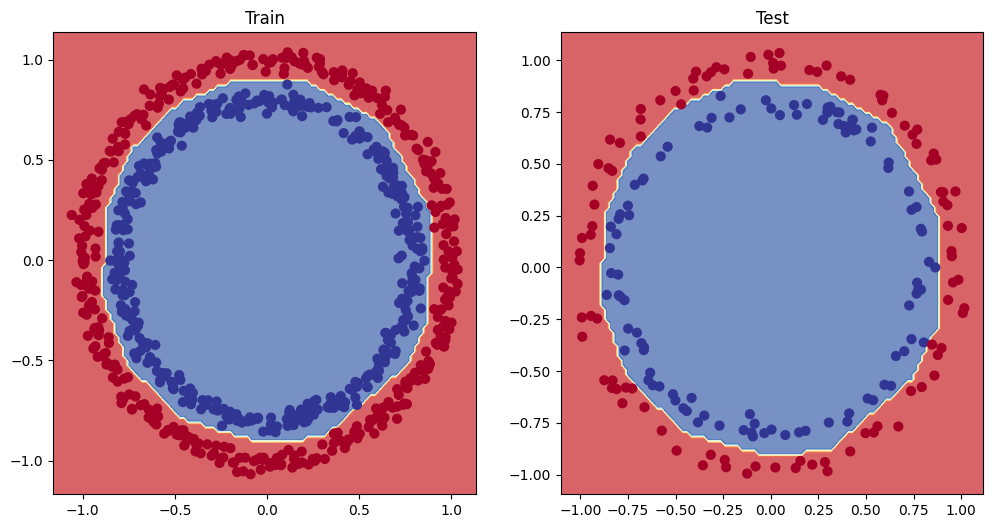

In [56]:
# Plot decision boundaries for training and test sets
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_0, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_0, X_test, y_test)

The model learnt a very descriptive boundary.

## Further Reading

To deepen your understanding of Neural Networks and Hyperparameter Tuning, consider exploring these resources:

### Neural Networks
*   **Deep Learning Book by Ian Goodfellow et al.:** [https://www.deeplearningbook.org/](https://www.deeplearningbook.org/) (A comprehensive academic resource)
*   **PyTorch Documentation:** [https://pytorch.org/docs/stable/index.html](https://pytorch.org/docs/stable/index.html) (Official documentation for PyTorch, including tutorials)
*   **3Blue1Brown's Neural Networks Series:** [https://www.youtube.com/playlist?list=PLZHQObOWTQDNU6R1_63RTN_V_Kq-d6cci](https://www.youtube.com/playlist?list=PLZHQObOWTQDNU6R1_63RTN_V_Kq-d6cci) (Visual and intuitive explanation of neural networks)

### Hyperparameter Tuning
*   **Keras Tuner:** [https://keras.io/keras_tuner/](https://keras.io/keras_tuner/) (A library for hyperparameter tuning with Keras models, concepts are broadly applicable)
*   **Optuna:** [https://optuna.org/](https://optuna.org/) (An open-source hyperparameter optimization framework)
*   **Grid Search vs. Random Search vs. Bayesian Optimization:** [https://towardsdatascience.com/grid-search-vs-random-search-vs-bayesian-optimization-5ee292c3071](https://towardsdatascience.com/grid-search-vs-random-search-vs-bayesian-optimization-5ee292c3071) (An article explaining different strategies for hyperparameter tuning)
*   **Learning Rate Schedulers in PyTorch:** [https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate](https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate) (Understanding how to dynamically change learning rates during training is a key aspect of tuning)
